

\

# **biometric ml project**



# Load data

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv(r'C:\Users\lenovo\OneDrive\Documents\hacktho\notebook\karnataka_aadhar_biometrics.csv')

# Corrected column assignment based on the error and common CSV structures
# Assuming the CSV columns are: index, state, district, pincode, bio_age_5_17, bio_age_17_plus, date
df.columns = ['index', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_plus', 'date']
df = df.drop('index', axis=1, errors='ignore')
df['date'] = pd.to_datetime(df['date'],  format='mixed', dayfirst=True, errors='coerce')

# Drop rows where 'date' is NaT
df.dropna(subset=['date'], inplace=True)

# Single numeric column
df['date_encoded'] = df['date'].apply(lambda x: x.toordinal())
df

,state,district,pincode,bio_age_5_17,bio_age_17_plus,date,date_encoded
74239,Karnataka,Davangere,577002,219,386,1970-01-01 00:00:00.000000030,719163
74240,Karnataka,Mysuru,571602,117,131,1970-01-01 00:00:00.000000051,719163
74241,Karnataka,Uttara Kannada,581344,15,7,1970-01-01 00:00:00.000000060,719163
74242,Karnataka,Udupi,574114,16,16,1970-01-01 00:00:00.000000062,719163
74243,Karnataka,Tumakuru,572225,16,3,1970-01-01 00:00:00.000000066,719163
...,...,...,...,...,...,...,...
112558,Karnataka,Yadgir,585304,2,3,1970-01-01 00:00:00.000498467,719163
112559,Karnataka,Yadgir,585315,4,11,1970-01-01 00:00:00.000498468,719163
112560,Karnataka,Yadgir,585323,5,4,1970-01-01 00:00:00.000498469,719163
112561,Karnataka,yadgir,585201,0,6,1970-01-01 00:00:00.000498470,719163


In [30]:
df = df.drop('date', axis=1)
df = df.drop('state', axis=1)


le_district = LabelEncoder()
df['district_label'] = le_district.fit_transform(df['district'])
df



,district,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
74239,Davangere,577002,219,386,719163,25
74240,Mysuru,571602,117,131,719163,40
74241,Uttara Kannada,581344,15,7,719163,49
74242,Udupi,574114,16,16,719163,47
74243,Tumakuru,572225,16,3,719163,45
...,...,...,...,...,...,...
112558,Yadgir,585304,2,3,719163,52
112559,Yadgir,585315,4,11,719163,52
112560,Yadgir,585323,5,4,719163,52
112561,yadgir,585201,0,6,719163,53


In [31]:
df_karnataka = df[df['district']=="Yadgir"]
print(len(df_karnataka))
df_karnataka




472


,district,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
74342,Yadgir,585223,272,246,719163,52
74660,Yadgir,585215,219,191,719163,52
74665,Yadgir,585216,328,340,719163,52
74674,Yadgir,585321,210,259,719163,52
74683,Yadgir,585214,187,166,719163,52
...,...,...,...,...,...,...
112191,Yadgir,585237,5,5,719163,52
112557,Yadgir,585287,7,4,719163,52
112558,Yadgir,585304,2,3,719163,52
112559,Yadgir,585315,4,11,719163,52


#data perparations



##Data separation as X and Y



In [32]:
y = df_karnataka[['bio_age_17_plus','bio_age_5_17']]
y

,bio_age_17_plus,bio_age_5_17
74342,246,272
74660,191,219
74665,340,328
74674,259,210
74683,166,187
...,...,...
112191,5,5
112557,4,7
112558,3,2
112559,11,4


In [33]:
x = df_karnataka.drop(['bio_age_17_plus','bio_age_5_17','district'],axis=1)
x

,pincode,date_encoded,district_label
74342,585223,719163,52
74660,585215,719163,52
74665,585216,719163,52
74674,585321,719163,52
74683,585214,719163,52
...,...,...,...
112191,585237,719163,52
112557,585287,719163,52
112558,585304,719163,52
112559,585315,719163,52


In [34]:
x = df_karnataka.drop(['district'],axis=1)
x

,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
74342,585223,272,246,719163,52
74660,585215,219,191,719163,52
74665,585216,328,340,719163,52
74674,585321,210,259,719163,52
74683,585214,187,166,719163,52
...,...,...,...,...,...
112191,585237,5,5,719163,52
112557,585287,7,4,719163,52
112558,585304,2,3,719163,52
112559,585315,4,11,719163,52


###data spliting


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100)

In [36]:
x_train


,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
76556,585291,126,103,719163,52
74674,585321,210,259,719163,52
104351,585223,23,23,719163,52
74794,585237,132,112,719163,52
102344,585215,2,0,719163,52
...,...,...,...,...,...
102346,585315,1,2,719163,52
103502,585202,8,2,719163,52
100348,585323,5,2,719163,52
96875,585319,10,2,719163,52


In [37]:
x_test

,pincode,bio_age_5_17,bio_age_17_plus,date_encoded,district_label
94706,585219,1,1,719163,52
92150,585216,4,6,719163,52
109668,585220,1,5,719163,52
91095,585216,2,1,719163,52
101745,585214,5,11,719163,52
...,...,...,...,...,...
91300,585323,0,1,719163,52
89684,585291,2,2,719163,52
87093,585317,1,0,719163,52
76881,585309,198,132,719163,52


## model building


###linear regression


##Training the model

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

**applying the model**

In [39]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)


In [40]:
y_lr_train_pred


array([[ 1.03000000e+02,  1.26000000e+02],
       [ 2.59000000e+02,  2.10000000e+02],
       [ 2.30000000e+01,  2.30000000e+01],
       [ 1.12000000e+02,  1.32000000e+02],
       [-1.64891799e-14,  2.00000000e+00],
       [ 9.00000000e+00,  1.10000000e+01],
       [ 2.00000000e+00, -2.88883401e-14],
       [ 6.00000000e+00,  7.00000000e+00],
       [ 1.17000000e+02,  2.31000000e+02],
       [ 1.43000000e+02,  1.56000000e+02],
       [ 2.76000000e+02,  2.65000000e+02],
       [ 2.00000000e+00,  1.00000000e+00],
       [ 1.91000000e+02,  2.19000000e+02],
       [ 9.00000000e+00,  2.20000000e+01],
       [ 8.00000000e+00,  7.00000000e+00],
       [ 9.00000000e+01,  1.01000000e+02],
       [ 5.00000000e+00,  3.00000000e+00],
       [ 1.41000000e+02,  1.24000000e+02],
       [ 1.00000000e+00,  4.00000000e+00],
       [ 1.10000000e+02,  2.18000000e+02],
       [ 1.20000000e+01,  4.00000000e+00],
       [ 1.10000000e+01,  2.00000000e+00],
       [ 1.00000000e+01,  1.10000000e+01],
       [-1.

In [41]:
y_lr_test_pred

array([[ 1.00000000e+00,  1.00000000e+00],
       [ 6.00000000e+00,  4.00000000e+00],
       [ 5.00000000e+00,  1.00000000e+00],
       [ 1.00000000e+00,  2.00000000e+00],
       [ 1.10000000e+01,  5.00000000e+00],
       [ 6.50000000e+01,  1.26000000e+02],
       [ 2.06000000e+02,  2.62000000e+02],
       [ 3.00000000e+00,  3.00000000e+00],
       [-1.56043111e-14,  7.00000000e+00],
       [ 1.40000000e+01,  5.00000000e+00],
       [ 3.00000000e+00,  6.00000000e+00],
       [ 1.10000000e+01,  1.00000000e+00],
       [ 6.00000000e+00,  8.00000000e+00],
       [ 7.00000000e+00,  5.00000000e+00],
       [ 1.20000000e+01,  4.00000000e+00],
       [ 3.00000000e+00,  2.00000000e+00],
       [ 3.10000000e+01,  4.60000000e+01],
       [ 4.68000000e+02,  3.94000000e+02],
       [ 2.00000000e+00,  2.00000000e+00],
       [ 3.00000000e+00, -3.06897787e-14],
       [ 4.00000000e+00,  7.00000000e+00],
       [ 8.00000000e+00,  8.00000000e+00],
       [-1.67667357e-14,  7.00000000e+00],
       [ 6.

#  Evaluate model performance

In [42]:
y_train

,bio_age_17_plus,bio_age_5_17
76556,103,126
74674,259,210
104351,23,23
74794,112,132
102344,0,2
...,...,...
102346,2,1
103502,2,8
100348,2,5
96875,2,10


In [43]:
from sklearn.metrics import mean_squared_error ,r2_score

lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)

In [44]:
print('LR MSE(Train):' , lr_train_mse)
print("LR R2 (Train): ",lr_train_r2)
print('LR MSE(Test):' , lr_test_mse)
print("LR R2 (Test): ",lr_test_r2)

LR MSE(Train): 5.641551202817242e-28
LR R2 (Train):  1.0
LR MSE(Test): 7.3603612814854745e-28
LR R2 (Test):  1.0


In [45]:
lr_result = pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']

In [46]:
lr_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0


## **Random Forest**

## Training the model

In [47]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(x_train, y_train)


RandomForestRegressor(max_depth=2, random_state=100)

# Applying the model to make performance

In [48]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

**Evaluate the model**

In [49]:
from sklearn.metrics import mean_squared_error ,r2_score

rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = r2_score(y_test,y_rf_test_pred)

In [50]:
rf_result = pd.DataFrame(['Random Forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_result.columns = ['Method','Training MSE','Training R2','Testing MSE','Testing R2']
rf_result

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest,495.298488,0.937576,585.33694,0.946598


**MODEL COMPARISION**

In [51]:
final_df_model = pd.concat([lr_result,rf_result],axis=0)
final_df_model.columns = ['Methods','Training MSE','Training R2','Testing MSE','Testing R2']
final_df_model
final_df_model.reset_index(drop=True)

,Methods,Training MSE,Training R2,Testing MSE,Testing R2
0,Linear Regression,0.0,1.0,0.0,1.0
1,Random Forest,495.298488,0.937576,585.33694,0.946598


# Data visualization of Prediction results

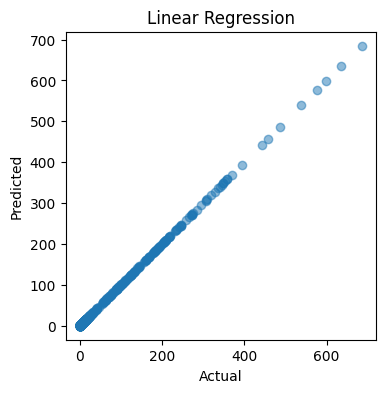

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(x=y_train, y=y_lr_train_pred,alpha=0.5)
plt.plot()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')
plt.show()